## XSCAPE Photon Cross Sections Compared to Data and PYTHIA Results

### Direct Photon Cross Sections

PTHAT 3-10 and 10-20 PYTHIA and XSCAPE cross sections

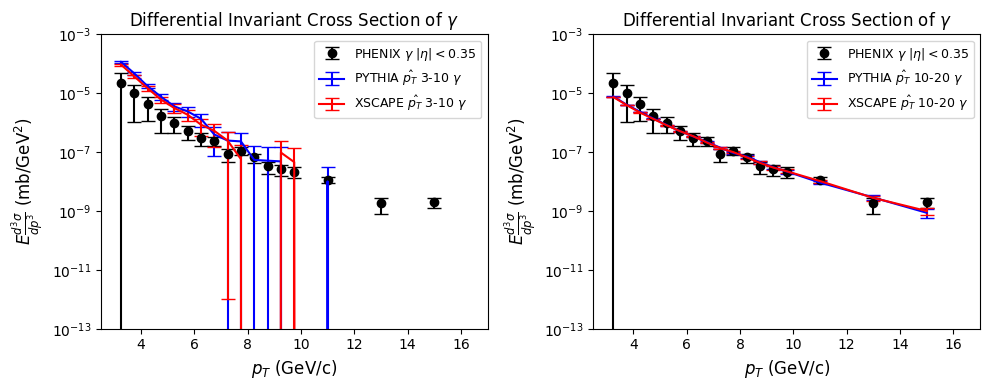

In [2]:
import numpy  as np
import matplotlib.pyplot as plt
import os
import subprocess
from IPython.display import display

# LO pQCD Calculations of Isolated and Fragmentation Photons
isolated = np.loadtxt('Cross Sections vs pT isolated 5.5_20.txt')
data = np.loadtxt('Existing Data for Cross Sections.txt')
fragmentation = np.loadtxt('Cross Sections vs pT fragmentation 5.5_20.txt')

isolated_momentum_T = isolated[:,0]
isolated_cross_sections = isolated[:,1]

fragmentation_momentum_T = fragmentation[:,0]
fragmentation_cross_sections = fragmentation[:,1]


# plt.plot(isolated_momentum_T,isolated_cross_sections,'--',color='orange',label='pQCD Iso $\gamma$')
# plt.plot(fragmentation_momentum_T, fragmentation_cross_sections,'--',color='g',label='pQCD Frag $\gamma$')
if (np.all(fragmentation_momentum_T==isolated_momentum_T)):
    # plt.plot(fragmentation_momentum_T,isolated_cross_sections+fragmentation_cross_sections, '-',color='black',label='LO pQCD Tot $\gamma$')
    total_pQCD_photon_cross_sec = isolated_cross_sections+fragmentation_cross_sections
# plt.ylim(1e-14,1e-3)
# plt.yscale('log')

# Existing PHENIX Photon Cross Sections
existing_photon_pT, existing_photon_cross_sec, existing_photon_stat_err, existing_photon_syst_err=np.loadtxt('Existing Data for Cross Sections.txt').T
existing_photon_cross_sec_err = np.sqrt(existing_photon_stat_err**2+existing_photon_syst_err**2)
# plt.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='.',label='PHENIX Tot $\gamma$')

# PYTHIA photon cross sections
photon_pythia_3_10_pT, photon_pythia_3_10_cross_sec, photon_pythia_3_10_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat3_10_cross_sec_v4_data_binning_1M.txt').T
photon_pythia_10_20_pT, photon_pythia_10_20_cross_sec, photon_pythia_10_20_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat10_20_cross_sec_v4_data_binning_1M.txt').T

# XSCAPE photon cross sections
photon_xscape_3_10_pT, photon_xscape_3_10_cross_sec, photon_xscape_3_10_cross_sec_err = np.loadtxt('photon_pp_pTHat3_10_cross_sec_v4_data_binning_1M.txt').T
photon_xscape_10_20_pT, photon_xscape_10_20_cross_sec, photon_xscape_10_20_cross_sec_err = np.loadtxt('photon_pp_pTHat10_20_cross_sec_v4_data_binning_1M.txt').T

# Plotting
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,4))

# Plotting Existing Photon Cross Sections
ax1.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')
ax2.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')

# Plotting PYTHIA Photon Cross Sections
ax1.errorbar(photon_pythia_3_10_pT, photon_pythia_3_10_cross_sec/2, yerr=photon_pythia_3_10_cross_sec_err, fmt = '-', color='blue', capsize=5, label='PYTHIA $\hat{p_{T}}$ 3-10 $\gamma$')
ax2.errorbar(photon_pythia_10_20_pT, photon_pythia_10_20_cross_sec/2, yerr=photon_pythia_10_20_cross_sec_err, fmt = '-', color='blue', capsize=5, label='PYTHIA $\hat{p_{T}}$ 10-20 $\gamma$')

# Plotting XSCAPE Photon Cross Sections
ax1.errorbar(photon_xscape_3_10_pT, photon_xscape_3_10_cross_sec/2, yerr=photon_xscape_3_10_cross_sec_err, fmt = '-', color='red', capsize=5, label='XSCAPE $\hat{p_{T}}$ 3-10 $\gamma$')
ax2.errorbar(photon_xscape_10_20_pT, photon_xscape_10_20_cross_sec/2, yerr=photon_xscape_10_20_cross_sec_err, fmt = '-', color='red', capsize=5, label='XSCAPE $\hat{p_{T}}$ 10-20 $\gamma$')

# More Plotting Parameters
# PTHat 5-10
ax1.set_ylim(1e-13,1e-3)
ax1.set_xlim(2.5,17)
ax1.set_yscale('log')
ax1.set_title(r'Differential Invariant Cross Section of $\gamma$')
ax1.set_xlabel('$p_T$ (GeV/c)',fontsize=12)
ax1.set_ylabel(r'$E \frac{d^3\sigma}{dp^3}$ (mb/GeV$^2$)',fontsize=12)
ax1.legend(fontsize=9)

# PTHat 10-15
ax2.set_ylim(1e-13,1e-3)
ax2.set_xlim(2.5,17)
ax2.set_yscale('log')
ax2.set_title(r'Differential Invariant Cross Section of $\gamma$')
ax2.set_xlabel('$p_T$ (GeV/c)',fontsize=12)
ax2.set_ylabel(r'$E \frac{d^3\sigma}{dp^3}$ (mb/GeV$^2$)',fontsize=12)
ax2.legend(fontsize=9)

plt.tight_layout()

# fig.savefig('XSCAPE_PYTHIA_cross_sec_color_virtuality_comparison_plots.png', dpi=300, bbox_inches='tight')
# if os.name == 'nt': #For Windows
#     os.startfile('XSCAPE_PYTHIA_cross_sec_color_virtuality_comparison_plots.png')
# else: # For macOS and Linux
#     subprocess.call(('open', 'XSCAPE_PYTHIA_cross_sec_color_virtuality_comparison_plots.png'))
    
# plt.title("Differential Cross Section Prompt&Hard GeV")
# plt.xlabel('$p_T$ (GeV/c)',fontsize=12)
# plt.ylabel('$E d^3\sigma/dp^3$ (mb/GeV$^2$)',fontsize=12)
# # plt.title('Direct Photon Production at RHIC $\sqrt{s}=200GeV$ compared to data')
# plt.legend()
plt.show()

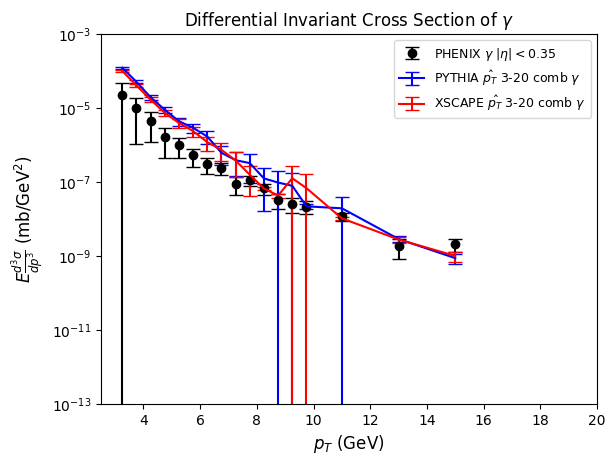

In [3]:
# Plotting PHENIX Photon Cross Section Data
plt.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')


plt.ylim(1e-13,1e-3)
plt.xlim(2.5,20)
plt.yscale('log')

# Combining PYTHIA pTHat 3-10 and 10-20
if (np.all(photon_pythia_3_10_pT==photon_pythia_10_20_pT)):
    photon_pythia_3_20_comb_cross_sec = photon_pythia_3_10_cross_sec+photon_pythia_10_20_cross_sec 
    photon_pythia_3_20_comb_cross_sec_err = np.sqrt(photon_pythia_3_10_cross_sec_err**2+photon_pythia_10_20_cross_sec_err**2)
    plt.errorbar(photon_pythia_10_20_pT, photon_pythia_3_20_comb_cross_sec/2, yerr=photon_pythia_3_20_comb_cross_sec_err, fmt='-', color='blue', capsize=5, label='PYTHIA $\hat{p_{T}}$ 3-20 comb $\gamma$')

# Combining XSCAPE pTHat 3-10 and 10-20
if (np.all(photon_xscape_3_10_pT==photon_xscape_10_20_pT)):
    photon_xscape_3_20_comb_cross_sec = photon_xscape_3_10_cross_sec+photon_xscape_10_20_cross_sec
    photon_xscape_3_20_comb_cross_sec_err = np.sqrt(photon_xscape_3_10_cross_sec_err**2+photon_xscape_10_20_cross_sec_err**2)
    plt.errorbar(photon_xscape_10_20_pT, photon_xscape_3_20_comb_cross_sec/2, yerr=photon_xscape_3_20_comb_cross_sec_err, fmt='-', color='red', capsize=5, label='XSCAPE $\hat{p_{T}}$ 3-20 comb $\gamma$')

plt.title('Differential Invariant Cross Section of $\gamma$')
plt.xlabel('$p_T$ (GeV)',fontsize=12)
plt.ylabel(r'$E \frac{d^{3}\sigma}{dp^{3}}$ (mb/GeV$^2$)',fontsize=12)
# plt.title('Direct Photon Production at RHIC $\sqrt{s}=200GeV$ compared to data')
plt.legend(fontsize=9)
# plt.text(4.3, 0.0000003, 'pp, $\sqrt{s_{NN}} = 200$ GeV', fontsize=12)
# plt.text(4.3, 0.00000015, '$|\eta| < 0.35$, $(\pi^{+}+\pi^{-})/2$', fontsize=12)
plt.show()

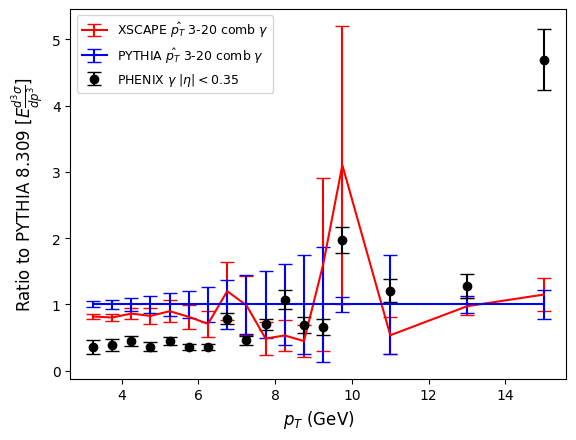

In [4]:
# Error Ratios for XSCAPE and PYTHIA
xscape_pythia_ratio_err = (photon_xscape_3_20_comb_cross_sec/photon_pythia_3_20_comb_cross_sec) * np.sqrt((photon_xscape_3_20_comb_cross_sec_err/photon_xscape_3_20_comb_cross_sec)**2 + (photon_pythia_3_20_comb_cross_sec_err/photon_pythia_3_20_comb_cross_sec)**2)
pythia_pythia_ratio_err = (photon_pythia_3_20_comb_cross_sec/photon_pythia_3_20_comb_cross_sec) * np.sqrt((photon_pythia_3_20_comb_cross_sec_err/photon_pythia_3_20_comb_cross_sec)**2 + (photon_pythia_3_20_comb_cross_sec_err/photon_pythia_3_20_comb_cross_sec)**2)
data_pythia_ratio_err = (existing_photon_cross_sec/photon_pythia_3_20_comb_cross_sec) * np.sqrt((existing_photon_cross_sec_err/existing_photon_cross_sec)**2 + (photon_pythia_3_20_comb_cross_sec_err/photon_pythia_3_20_comb_cross_sec)**2)

# Plotting the XSCAPE / PYTHIA and PYTHIA / PYTHIA ratios
plt.errorbar(photon_xscape_10_20_pT, (photon_xscape_3_20_comb_cross_sec)/photon_pythia_3_20_comb_cross_sec, yerr=xscape_pythia_ratio_err, fmt='-', color='red', capsize=5, label='XSCAPE $\hat{p_{T}}$ 3-20 comb $\gamma$')
plt.errorbar(photon_pythia_10_20_pT, (photon_pythia_3_20_comb_cross_sec)/photon_pythia_3_20_comb_cross_sec, yerr=pythia_pythia_ratio_err, fmt='-', color='blue', capsize=5, label='PYTHIA $\hat{p_{T}}$ 3-20 comb $\gamma$')
plt.errorbar(existing_photon_pT, (4*existing_photon_cross_sec)/photon_pythia_3_20_comb_cross_sec, yerr=data_pythia_ratio_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')

# plt.ylim(-1.5,3.5)
# plt.xlim(5,20)
# plt.title('Ratio to PYTHIA (Cross Section of $\pi^{+}$)')
plt.xlabel('$p_T$ (GeV)',fontsize=12)
plt.ylabel(r'Ratio to PYTHIA 8.309 [$E \frac{d^{3}\sigma}{dp^{3}}$]',fontsize=12)
plt.legend(fontsize=9)
# plt.text(10.5, 1.7, 'pp, $\sqrt{s_{NN}} = 200$ GeV', fontsize=12)
# plt.text(10.5, 1.5, '$|\eta| < 0.35$, $(\pi^{+}+\pi^{-})/2$', fontsize=12)

plt.show()

PTHAT 5-25

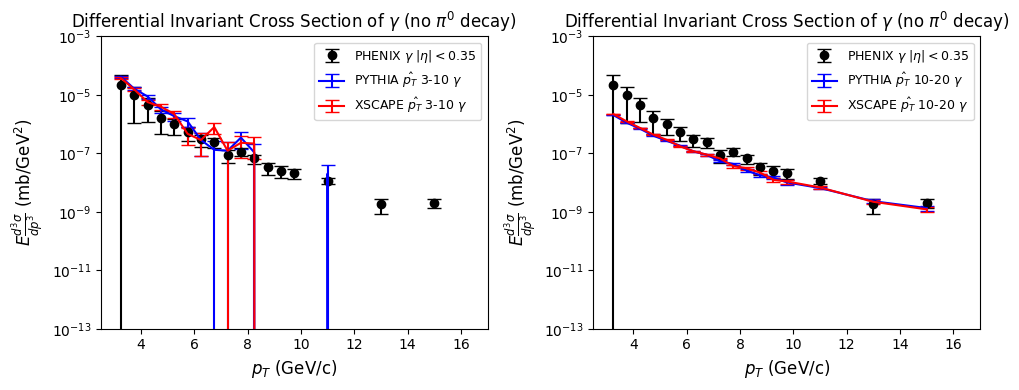

In [5]:
import numpy  as np
import matplotlib.pyplot as plt
import os
import subprocess
from IPython.display import display

# LO pQCD Calculations of Isolated and Fragmentation Photons
isolated = np.loadtxt('Cross Sections vs pT isolated 5.5_20.txt')
data = np.loadtxt('Existing Data for Cross Sections.txt')
fragmentation = np.loadtxt('Cross Sections vs pT fragmentation 5.5_20.txt')

isolated_momentum_T = isolated[:,0]
isolated_cross_sections = isolated[:,1]

fragmentation_momentum_T = fragmentation[:,0]
fragmentation_cross_sections = fragmentation[:,1]


# plt.plot(isolated_momentum_T,isolated_cross_sections,'--',color='orange',label='pQCD Iso $\gamma$')
# plt.plot(fragmentation_momentum_T, fragmentation_cross_sections,'--',color='g',label='pQCD Frag $\gamma$')
if (np.all(fragmentation_momentum_T==isolated_momentum_T)):
    # plt.plot(fragmentation_momentum_T,isolated_cross_sections+fragmentation_cross_sections, '-',color='black',label='LO pQCD Tot $\gamma$')
    total_pQCD_photon_cross_sec = isolated_cross_sections+fragmentation_cross_sections
# plt.ylim(1e-14,1e-3)
# plt.yscale('log')

# Existing PHENIX Photon Cross Sections
existing_photon_pT, existing_photon_cross_sec, existing_photon_stat_err, existing_photon_syst_err=np.loadtxt('Existing Data for Cross Sections.txt').T
existing_photon_cross_sec_err = np.sqrt(existing_photon_stat_err**2+existing_photon_syst_err**2)
# plt.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='.',label='PHENIX Tot $\gamma$')

# PYTHIA photon cross sections without pi0 decay
photon_pythia_3_10_pi0decayoff_pT, photon_pythia_3_10_pi0decayoff_cross_sec, photon_pythia_3_10_pi0decayoff_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat3_10_pi0decayoff_cross_sec_v4_data_binning_1M.txt').T
photon_pythia_10_20_pi0decayoff_pT, photon_pythia_10_20_pi0decayoff_cross_sec, photon_pythia_10_20_pi0decayoff_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat10_20_pi0decayoff_cross_sec_v4_data_binning_1M.txt').T

# XSCAPE photon cross sections without pi0 decay
photon_xscape_3_10_pi0decayoff_pT, photon_xscape_3_10_pi0decayoff_cross_sec, photon_xscape_3_10_pi0decayoff_cross_sec_err = np.loadtxt('photon_pp_pTHat3_10_pi0decayoff_cross_sec_v4_data_binning_1M.txt').T
photon_xscape_10_20_pi0decayoff_pT, photon_xscape_10_20_pi0decayoff_cross_sec, photon_xscape_10_20_pi0decayoff_cross_sec_err = np.loadtxt('photon_pp_pTHat10_20_pi0decayoff_cross_sec_v4_data_binning_1M.txt').T

# Plotting
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,4))

# Plotting Existing Photon Cross Sections
ax1.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')
ax2.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')

# Plotting PYTHIA Photon Cross Sections
ax1.errorbar(existing_photon_pT, photon_pythia_3_10_pi0decayoff_cross_sec, yerr=photon_pythia_3_10_pi0decayoff_cross_sec_err, fmt = '-', color='blue', capsize=5, label='PYTHIA $\hat{p_{T}}$ 3-10 $\gamma$')
ax2.errorbar(existing_photon_pT, photon_pythia_10_20_pi0decayoff_cross_sec, yerr=photon_pythia_10_20_pi0decayoff_cross_sec_err, fmt = '-', color='blue', capsize=5, label='PYTHIA $\hat{p_{T}}$ 10-20 $\gamma$')

# Plotting XSCAPE Photon Cross Sections
ax1.errorbar(existing_photon_pT, photon_xscape_3_10_pi0decayoff_cross_sec, yerr=photon_xscape_3_10_pi0decayoff_cross_sec_err, fmt = '-', color='red', capsize=5, label='XSCAPE $\hat{p_{T}}$ 3-10 $\gamma$')
ax2.errorbar(existing_photon_pT, photon_xscape_10_20_pi0decayoff_cross_sec, yerr=photon_xscape_10_20_pi0decayoff_cross_sec_err, fmt = '-', color='red', capsize=5, label='XSCAPE $\hat{p_{T}}$ 10-20 $\gamma$')

# More Plotting Parameters
# PTHat 5-10
ax1.set_ylim(1e-13,1e-3)
ax1.set_xlim(2.5,17)
ax1.set_yscale('log')
ax1.set_title(r'Differential Invariant Cross Section of $\gamma$ (no $\pi^{0}$ decay)')
ax1.set_xlabel('$p_T$ (GeV/c)',fontsize=12)
ax1.set_ylabel(r'$E \frac{d^3\sigma}{dp^3}$ (mb/GeV$^2$)',fontsize=12)
ax1.legend(fontsize=9)

# PTHat 10-15
ax2.set_ylim(1e-13,1e-3)
ax2.set_xlim(2.5,17)
ax2.set_yscale('log')
ax2.set_title(r'Differential Invariant Cross Section of $\gamma$ (no $\pi^{0}$ decay)')
ax2.set_xlabel('$p_T$ (GeV/c)',fontsize=12)
ax2.set_ylabel(r'$E \frac{d^3\sigma}{dp^3}$ (mb/GeV$^2$)',fontsize=12)
ax2.legend(fontsize=9)

plt.tight_layout()

# fig.savefig('XSCAPE_PYTHIA_cross_sec_color_virtuality_comparison_plots.png', dpi=300, bbox_inches='tight')
# if os.name == 'nt': #For Windows
#     os.startfile('XSCAPE_PYTHIA_cross_sec_color_virtuality_comparison_plots.png')
# else: # For macOS and Linux
#     subprocess.call(('open', 'XSCAPE_PYTHIA_cross_sec_color_virtuality_comparison_plots.png'))
    
# plt.title("Differential Cross Section Prompt&Hard GeV")
# plt.xlabel('$p_T$ (GeV/c)',fontsize=12)
# plt.ylabel('$E d^3\sigma/dp^3$ (mb/GeV$^2$)',fontsize=12)
# # plt.title('Direct Photon Production at RHIC $\sqrt{s}=200GeV$ compared to data')
# plt.legend()
plt.show()

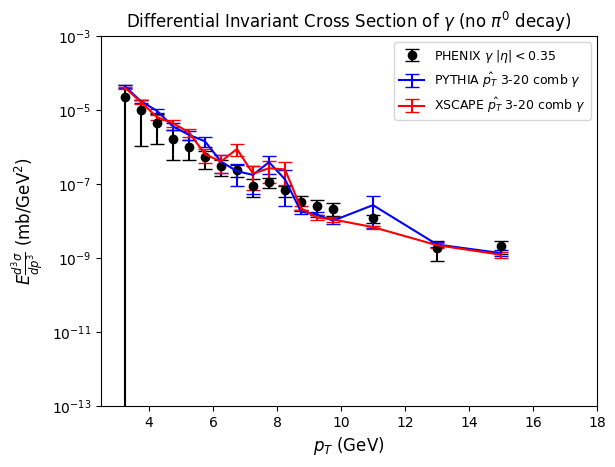

In [6]:
# Plotting PHENIX Photon Cross Section Data
plt.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')


plt.ylim(1e-13,1e-3)
plt.xlim(2.5,18)
plt.yscale('log')

# Combining PYTHIA pTHat 3-10 and 10-20
if (np.all(photon_pythia_3_10_pi0decayoff_pT==photon_pythia_10_20_pi0decayoff_pT)):
    photon_pythia_3_20_comb_pi0decayoff_cross_sec = photon_pythia_3_10_pi0decayoff_cross_sec+photon_pythia_10_20_pi0decayoff_cross_sec 
    photon_pythia_3_20_comb_pi0decayoff_cross_sec_err = np.sqrt(photon_pythia_3_10_pi0decayoff_cross_sec_err**2+photon_pythia_10_20_pi0decayoff_cross_sec_err**2)
    plt.errorbar(existing_photon_pT, photon_pythia_3_20_comb_pi0decayoff_cross_sec, yerr=photon_pythia_3_20_comb_pi0decayoff_cross_sec_err, fmt='-', color='blue', capsize=5, label='PYTHIA $\hat{p_{T}}$ 3-20 comb $\gamma$')

# Combining XSCAPE pTHat 3-10 and 10-20
if (np.all(photon_xscape_3_10_pi0decayoff_pT==photon_xscape_10_20_pi0decayoff_pT)):
    photon_xscape_3_20_comb_pi0decayoff_cross_sec = photon_xscape_3_10_pi0decayoff_cross_sec+photon_xscape_10_20_pi0decayoff_cross_sec
    photon_xscape_3_20_comb_pi0decayoff_cross_sec_err = np.sqrt(photon_xscape_3_10_pi0decayoff_cross_sec_err**2+photon_xscape_10_20_pi0decayoff_cross_sec_err**2)
    plt.errorbar(existing_photon_pT, photon_xscape_3_20_comb_pi0decayoff_cross_sec, yerr=photon_xscape_3_20_comb_pi0decayoff_cross_sec_err, fmt='-', color='red', capsize=5, label='XSCAPE $\hat{p_{T}}$ 3-20 comb $\gamma$')

plt.title('Differential Invariant Cross Section of $\gamma$ (no $\pi^{0}$ decay)')
plt.xlabel('$p_T$ (GeV)',fontsize=12)
plt.ylabel(r'$E \frac{d^{3}\sigma}{dp^{3}}$ (mb/GeV$^2$)',fontsize=12)
# plt.title('Direct Photon Production at RHIC $\sqrt{s}=200GeV$ compared to data')
plt.legend(fontsize=9)
# plt.text(4.3, 0.0000003, 'pp, $\sqrt{s_{NN}} = 200$ GeV', fontsize=12)
# plt.text(4.3, 0.00000015, '$|\eta| < 0.35$, $(\pi^{+}+\pi^{-})/2$', fontsize=12)
plt.show()

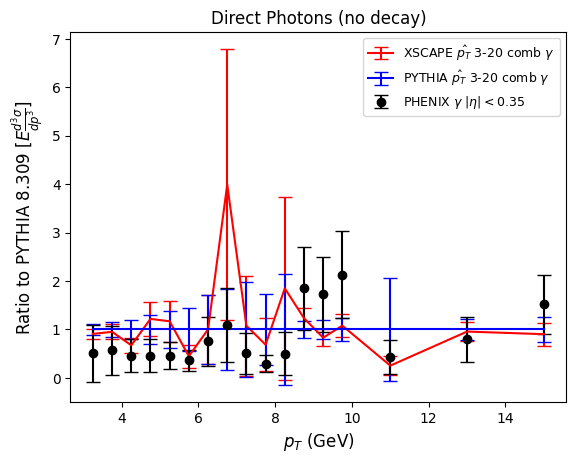

In [7]:
# Error Ratios for XSCAPE and PYTHIA
xscape_pythia_pi0decayoff_ratio_err = (photon_xscape_3_20_comb_pi0decayoff_cross_sec/photon_pythia_3_20_comb_pi0decayoff_cross_sec) * np.sqrt((photon_xscape_3_20_comb_pi0decayoff_cross_sec_err/photon_xscape_3_20_comb_pi0decayoff_cross_sec)**2 + (photon_pythia_3_20_comb_pi0decayoff_cross_sec_err/photon_pythia_3_20_comb_pi0decayoff_cross_sec)**2)
pythia_pythia_pi0decayoff_ratio_err = (photon_pythia_3_20_comb_pi0decayoff_cross_sec/photon_pythia_3_20_comb_pi0decayoff_cross_sec) * np.sqrt((photon_pythia_3_20_comb_pi0decayoff_cross_sec_err/photon_pythia_3_20_comb_pi0decayoff_cross_sec)**2 + (photon_pythia_3_20_comb_pi0decayoff_cross_sec_err/photon_pythia_3_20_comb_pi0decayoff_cross_sec)**2)
data_pythia_pi0decayoff_ratio_err = (existing_photon_cross_sec/photon_pythia_3_20_comb_pi0decayoff_cross_sec) * np.sqrt((existing_photon_cross_sec_err/existing_photon_cross_sec)**2 + (photon_pythia_3_20_comb_pi0decayoff_cross_sec_err/photon_pythia_3_20_comb_pi0decayoff_cross_sec)**2)

# Plotting the XSCAPE / PYTHIA and PYTHIA / PYTHIA ratios
plt.errorbar(existing_photon_pT, (photon_xscape_3_20_comb_pi0decayoff_cross_sec)/photon_pythia_3_20_comb_pi0decayoff_cross_sec, yerr=xscape_pythia_pi0decayoff_ratio_err, fmt='-', color='red', capsize=5, label='XSCAPE $\hat{p_{T}}$ 3-20 comb $\gamma$')
plt.errorbar(existing_photon_pT, (photon_pythia_3_20_comb_pi0decayoff_cross_sec)/photon_pythia_3_20_comb_pi0decayoff_cross_sec, yerr=pythia_pythia_pi0decayoff_ratio_err, fmt='-', color='blue', capsize=5, label='PYTHIA $\hat{p_{T}}$ 3-20 comb $\gamma$')
plt.errorbar(existing_photon_pT, (existing_photon_cross_sec)/photon_pythia_3_20_comb_pi0decayoff_cross_sec, yerr=data_pythia_pi0decayoff_ratio_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')

# plt.ylim(-1.5,3.5)
# plt.xlim(5,20)
plt.title('Direct Photons (no decay)')
plt.xlabel('$p_T$ (GeV)',fontsize=12)
plt.ylabel(r'Ratio to PYTHIA 8.309 [$E \frac{d^{3}\sigma}{dp^{3}}$]',fontsize=12)
plt.legend(fontsize=9)
# plt.text(10.5, 1.7, 'pp, $\sqrt{s_{NN}} = 200$ GeV', fontsize=12)
# plt.text(10.5, 1.5, '$|\eta| < 0.35$, $(\pi^{+}+\pi^{-})/2$', fontsize=12)

plt.show()

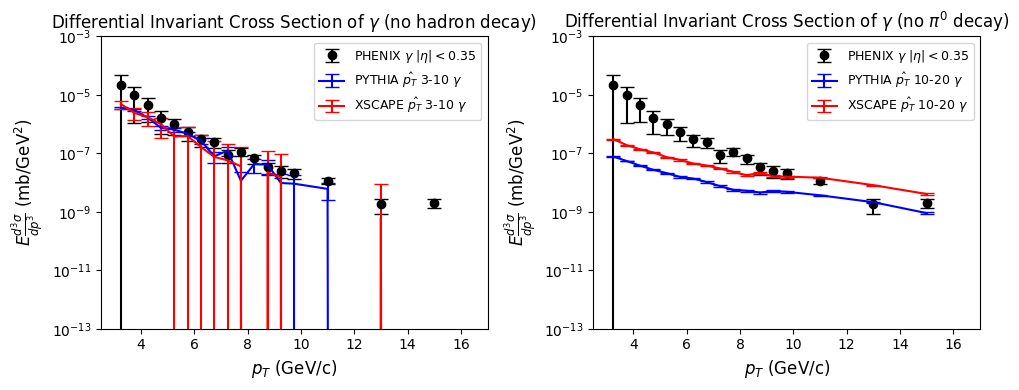

In [8]:
import numpy  as np
import matplotlib.pyplot as plt
import os
import subprocess
from IPython.display import display

# # LO pQCD Calculations of Isolated and Fragmentation Photons
# isolated = np.loadtxt('Cross Sections vs pT isolated 5.5_20.txt')
# data = np.loadtxt('Existing Data for Cross Sections.txt')
# fragmentation = np.loadtxt('Cross Sections vs pT fragmentation 5.5_20.txt')

# isolated_momentum_T = isolated[:,0]
# isolated_cross_sections = isolated[:,1]

# fragmentation_momentum_T = fragmentation[:,0]
# fragmentation_cross_sections = fragmentation[:,1]


# plt.plot(isolated_momentum_T,isolated_cross_sections,'--',color='orange',label='pQCD Iso $\gamma$')
# plt.plot(fragmentation_momentum_T, fragmentation_cross_sections,'--',color='g',label='pQCD Frag $\gamma$')
if (np.all(fragmentation_momentum_T==isolated_momentum_T)):
    # plt.plot(fragmentation_momentum_T,isolated_cross_sections+fragmentation_cross_sections, '-',color='black',label='LO pQCD Tot $\gamma$')
    total_pQCD_photon_cross_sec = isolated_cross_sections+fragmentation_cross_sections
# plt.ylim(1e-14,1e-3)
# plt.yscale('log')

# Existing PHENIX Photon Cross Sections
# existing_photon_pT, existing_photon_cross_sec, existing_photon_stat_err, existing_photon_syst_err=np.loadtxt('Existing Data for Cross Sections.txt').T
existing_photon_cross_sec_err = np.sqrt(existing_photon_stat_err**2+existing_photon_syst_err**2)
# plt.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='.',label='PHENIX Tot $\gamma$')

# PYTHIA photon cross sections without pi0 decay
photon_pythia_3_10_alldecayoff_pT, photon_pythia_3_10_alldecayoff_cross_sec, photon_pythia_3_10_alldecayoff_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat3_10_alldecayoff_cross_sec_v4_data_binning_10M_fixedPID.txt').T
photon_pythia_10_20_alldecayoff_pT, photon_pythia_10_20_alldecayoff_cross_sec, photon_pythia_10_20_alldecayoff_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat10_20_alldecayoff_cross_sec_v4_data_binning_10M_fixedPID.txt').T

# XSCAPE photon cross sections without pi0 decay
photon_xscape_3_10_alldecayoff_pT, photon_xscape_3_10_alldecayoff_cross_sec, photon_xscape_3_10_alldecayoff_cross_sec_err = np.loadtxt('photon_pp_pTHat3_10_alldecayoff_cross_sec_v4_data_binning_10M_fixedPID.txt').T
# photon_xscape_3_10_test_alldecayoff_pT, photon_xscape_3_10_test_alldecayoff_cross_sec, photon_xscape_3_10_test_alldecayoff_cross_sec_err = np.loadtxt('test_3_10.txt').T

photon_xscape_10_20_alldecayoff_pT, photon_xscape_10_20_alldecayoff_cross_sec, photon_xscape_10_20_alldecayoff_cross_sec_err = np.loadtxt('photon_pp_pTHat10_20_alldecayoff_cross_sec_v4_data_binning_10M_fixedPID.txt').T

# Plotting
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,4))

# Plotting Existing Photon Cross Sections
ax1.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')
ax2.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')

# Plotting PYTHIA Photon Cross Sections
ax1.errorbar(existing_photon_pT, photon_pythia_3_10_alldecayoff_cross_sec, yerr=photon_pythia_3_10_alldecayoff_cross_sec_err, fmt = '-', color='blue', capsize=5, label='PYTHIA $\hat{p_{T}}$ 3-10 $\gamma$')
ax2.errorbar(existing_photon_pT, photon_pythia_10_20_alldecayoff_cross_sec, yerr=photon_pythia_10_20_alldecayoff_cross_sec_err, fmt = '-', color='blue', capsize=5, label='PYTHIA $\hat{p_{T}}$ 10-20 $\gamma$')

# Plotting XSCAPE Photon Cross Sections
ax1.errorbar(existing_photon_pT, photon_xscape_3_10_alldecayoff_cross_sec/existing_photon_pT, yerr=photon_xscape_3_10_alldecayoff_cross_sec_err, fmt = '-', color='red', capsize=5, label='XSCAPE $\hat{p_{T}}$ 3-10 $\gamma$')
# ax1.errorbar(existing_photon_pT, photon_xscape_3_10_test_alldecayoff_cross_sec/(existing_photon_pT), yerr=photon_xscape_3_10_test_alldecayoff_cross_sec_err, fmt = '-', color='red', capsize=5, label='XSCAPE $\hat{p_{T}}$ 3-10 $\gamma$')
ax2.errorbar(existing_photon_pT, photon_xscape_10_20_alldecayoff_cross_sec, yerr=photon_xscape_10_20_alldecayoff_cross_sec_err, fmt = '-', color='red', capsize=5, label='XSCAPE $\hat{p_{T}}$ 10-20 $\gamma$')

# More Plotting Parameters
# PTHat 5-10
ax1.set_ylim(1e-13,1e-3)
ax1.set_xlim(2.5,17)
ax1.set_yscale('log')
ax1.set_title(r'Differential Invariant Cross Section of $\gamma$ (no hadron decay)')
ax1.set_xlabel('$p_T$ (GeV/c)',fontsize=12)
ax1.set_ylabel(r'$E \frac{d^3\sigma}{dp^3}$ (mb/GeV$^2$)',fontsize=12)
ax1.legend(fontsize=9)

# PTHat 10-15
ax2.set_ylim(1e-13,1e-3)
ax2.set_xlim(2.5,17)
ax2.set_yscale('log')
ax2.set_title(r'Differential Invariant Cross Section of $\gamma$ (no $\pi^{0}$ decay)')
ax2.set_xlabel('$p_T$ (GeV/c)',fontsize=12)
ax2.set_ylabel(r'$E \frac{d^3\sigma}{dp^3}$ (mb/GeV$^2$)',fontsize=12)
ax2.legend(fontsize=9)

plt.tight_layout()

# fig.savefig('XSCAPE_PYTHIA_cross_sec_color_virtuality_comparison_plots.png', dpi=300, bbox_inches='tight')
# if os.name == 'nt': #For Windows
#     os.startfile('XSCAPE_PYTHIA_cross_sec_color_virtuality_comparison_plots.png')
# else: # For macOS and Linux
#     subprocess.call(('open', 'XSCAPE_PYTHIA_cross_sec_color_virtuality_comparison_plots.png'))
    
# plt.title("Differential Cross Section Prompt&Hard GeV")
# plt.xlabel('$p_T$ (GeV/c)',fontsize=12)
# plt.ylabel('$E d^3\sigma/dp^3$ (mb/GeV$^2$)',fontsize=12)
# # plt.title('Direct Photon Production at RHIC $\sqrt{s}=200GeV$ compared to data')
# plt.legend()
plt.show()

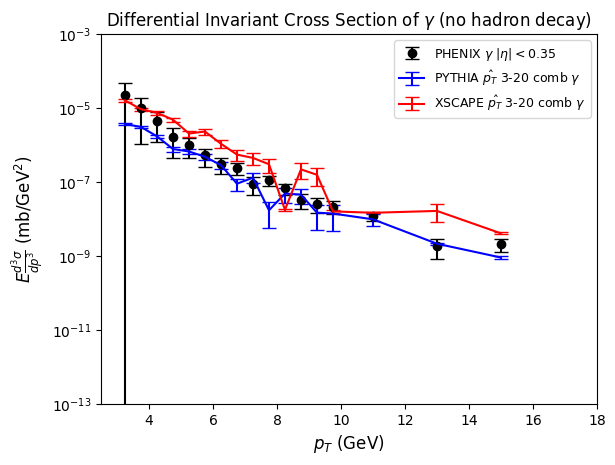

In [9]:
# Plotting PHENIX Photon Cross Section Data
plt.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')


plt.ylim(1e-13,1e-3)
plt.xlim(2.5,18)
plt.yscale('log')

# Combining PYTHIA pTHat 3-10 and 10-20
if (np.all(photon_pythia_3_10_alldecayoff_pT==photon_pythia_10_20_alldecayoff_pT)):
    photon_pythia_3_20_comb_alldecayoff_cross_sec =(photon_pythia_3_10_alldecayoff_cross_sec)+(photon_pythia_10_20_alldecayoff_cross_sec) 
    photon_pythia_3_20_comb_alldecayoff_cross_sec_err = np.sqrt(photon_pythia_3_10_alldecayoff_cross_sec_err**2+photon_pythia_10_20_alldecayoff_cross_sec_err**2)
    # photon_pythia_3_10_alldecayoff_cross_sec_weight = 1 / (photon_pythia_3_10_alldecayoff_cross_sec_err)**2
    # photon_pythia_10_20_alldecayoff_cross_sec_weight = 1 / (photon_pythia_10_20_alldecayoff_cross_sec_err)**2
    # photon_pythia_3_20_comb_alldecayoff_cross_sec = (photon_pythia_3_10_alldecayoff_cross_sec*photon_pythia_3_10_alldecayoff_cross_sec_weight + photon_pythia_10_20_alldecayoff_cross_sec*photon_pythia_10_20_alldecayoff_cross_sec_weight) / (photon_pythia_3_10_alldecayoff_cross_sec_weight + photon_pythia_10_20_alldecayoff_cross_sec_weight)
    # photon_pythia_3_20_comb_alldecayoff_cross_sec_err = 1 / np.sqrt((1/photon_pythia_3_10_alldecayoff_cross_sec_err)**2+(1/photon_pythia_10_20_alldecayoff_cross_sec_err**2))
    plt.errorbar(existing_photon_pT, photon_pythia_3_20_comb_alldecayoff_cross_sec, yerr=photon_pythia_3_20_comb_alldecayoff_cross_sec_err, fmt='-', color='blue', capsize=5, label='PYTHIA $\hat{p_{T}}$ 3-20 comb $\gamma$')

# Combining XSCAPE pTHat 3-10 and 10-20
if (np.all(photon_xscape_3_10_alldecayoff_pT==photon_xscape_10_20_alldecayoff_pT)):
    photon_xscape_3_20_comb_alldecayoff_cross_sec = (photon_xscape_3_10_alldecayoff_cross_sec)+(photon_xscape_10_20_alldecayoff_cross_sec)
    photon_xscape_3_20_comb_alldecayoff_cross_sec_err = np.sqrt(photon_xscape_3_10_alldecayoff_cross_sec_err**2+photon_xscape_10_20_alldecayoff_cross_sec_err**2)
    # photon_xscape_3_10_alldecayoff_cross_sec_weight = 1 / (photon_xscape_3_10_alldecayoff_cross_sec_err)**2
    # photon_xscape_10_20_alldecayoff_cross_sec_weight = 1 / (photon_xscape_10_20_alldecayoff_cross_sec_err)**2
    # photon_xscape_3_20_comb_alldecayoff_cross_sec = (photon_xscape_3_10_alldecayoff_cross_sec*photon_xscape_3_10_alldecayoff_cross_sec_weight + photon_xscape_10_20_alldecayoff_cross_sec*photon_xscape_10_20_alldecayoff_cross_sec_weight) / (photon_xscape_3_10_alldecayoff_cross_sec_weight + photon_xscape_10_20_alldecayoff_cross_sec_weight)
    # photon_xscape_3_20_comb_alldecayoff_cross_sec_err = 1 / np.sqrt((1/photon_xscape_3_10_alldecayoff_cross_sec_err)**2+(1/photon_xscape_10_20_alldecayoff_cross_sec_err**2))
    plt.errorbar(existing_photon_pT, photon_xscape_3_20_comb_alldecayoff_cross_sec, yerr=photon_xscape_3_20_comb_alldecayoff_cross_sec_err, fmt='-', color='red', capsize=5, label='XSCAPE $\hat{p_{T}}$ 3-20 comb $\gamma$')

plt.title('Differential Invariant Cross Section of $\gamma$ (no hadron decay)')
plt.xlabel('$p_T$ (GeV)',fontsize=12)
plt.ylabel(r'$E \frac{d^{3}\sigma}{dp^{3}}$ (mb/GeV$^2$)',fontsize=12)
# plt.title('Direct Photon Production at RHIC $\sqrt{s}=200GeV$ compared to data')
plt.legend(fontsize=9)
# plt.text(4.3, 0.0000003, 'pp, $\sqrt{s_{NN}} = 200$ GeV', fontsize=12)
# plt.text(4.3, 0.00000015, '$|\eta| < 0.35$, $(\pi^{+}+\pi^{-})/2$', fontsize=12)
plt.show()

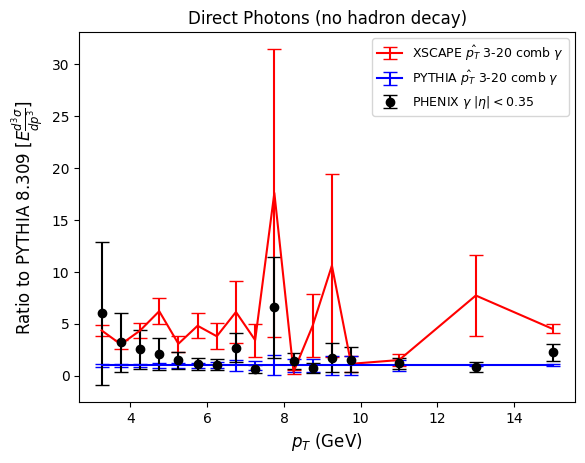

In [10]:
# Error Ratios for XSCAPE and PYTHIA
xscape_pythia_alldecayoff_ratio_err = (photon_xscape_3_20_comb_alldecayoff_cross_sec/photon_pythia_3_20_comb_alldecayoff_cross_sec) * np.sqrt((photon_xscape_3_20_comb_alldecayoff_cross_sec_err/photon_xscape_3_20_comb_alldecayoff_cross_sec)**2 + (photon_pythia_3_20_comb_alldecayoff_cross_sec_err/photon_pythia_3_20_comb_alldecayoff_cross_sec)**2)
pythia_pythia_alldecayoff_ratio_err = (photon_pythia_3_20_comb_alldecayoff_cross_sec/photon_pythia_3_20_comb_alldecayoff_cross_sec) * np.sqrt((photon_pythia_3_20_comb_alldecayoff_cross_sec_err/photon_pythia_3_20_comb_alldecayoff_cross_sec)**2 + (photon_pythia_3_20_comb_alldecayoff_cross_sec_err/photon_pythia_3_20_comb_alldecayoff_cross_sec)**2)
data_pythia_alldecayoff_ratio_err = (existing_photon_cross_sec/photon_pythia_3_20_comb_alldecayoff_cross_sec) * np.sqrt((existing_photon_cross_sec_err/existing_photon_cross_sec)**2 + (photon_pythia_3_20_comb_alldecayoff_cross_sec_err/photon_pythia_3_20_comb_alldecayoff_cross_sec)**2)

# Plotting the XSCAPE / PYTHIA and PYTHIA / PYTHIA ratios
plt.errorbar(existing_photon_pT, (photon_xscape_3_20_comb_alldecayoff_cross_sec)/photon_pythia_3_20_comb_alldecayoff_cross_sec, yerr=xscape_pythia_alldecayoff_ratio_err, fmt='-', color='red', capsize=5, label='XSCAPE $\hat{p_{T}}$ 3-20 comb $\gamma$')
plt.errorbar(existing_photon_pT, (photon_pythia_3_20_comb_alldecayoff_cross_sec)/photon_pythia_3_20_comb_alldecayoff_cross_sec, yerr=pythia_pythia_alldecayoff_ratio_err, fmt='-', color='blue', capsize=5, label='PYTHIA $\hat{p_{T}}$ 3-20 comb $\gamma$')
plt.errorbar(existing_photon_pT, (existing_photon_cross_sec)/photon_pythia_3_20_comb_alldecayoff_cross_sec, yerr=data_pythia_alldecayoff_ratio_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')

# plt.ylim(-1.5,3.5)
# plt.xlim(5,20)
plt.title('Direct Photons (no hadron decay)')
plt.xlabel('$p_T$ (GeV)',fontsize=12)
plt.ylabel(r'Ratio to PYTHIA 8.309 [$E \frac{d^{3}\sigma}{dp^{3}}$]',fontsize=12)
plt.legend(fontsize=9)
# plt.text(10.5, 1.7, 'pp, $\sqrt{s_{NN}} = 200$ GeV', fontsize=12)
# plt.text(10.5, 1.5, '$|\eta| < 0.35$, $(\pi^{+}+\pi^{-})/2$', fontsize=12)

plt.show()

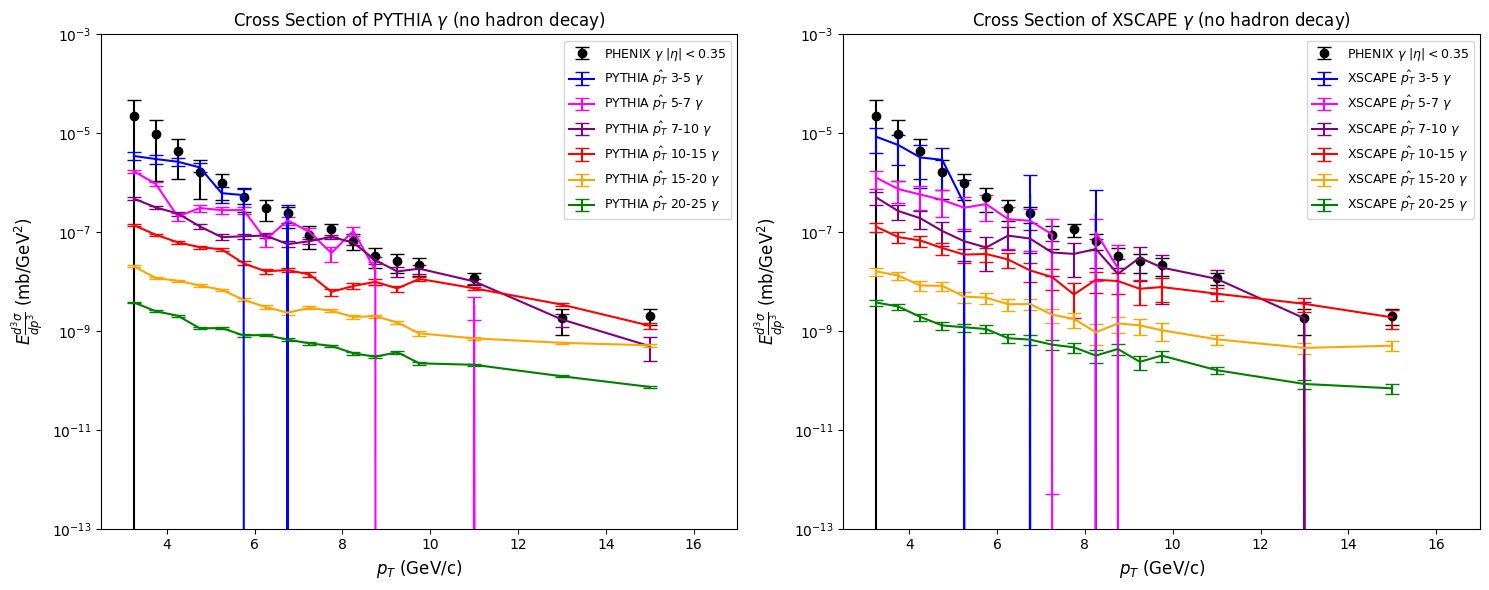

In [11]:

# PYTHIA direct photons pTHat 3-7, 7-10, 10-15, 15-20 cross sections
# photon_pythia_3_7_pT, photon_pythia_3_7_cross_sec, photon_pythia_3_7_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat3_7_alldecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_pythia_3_5_pT, photon_pythia_3_5_cross_sec, photon_pythia_3_5_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat3_5_alldecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_pythia_5_7_pT, photon_pythia_5_7_cross_sec, photon_pythia_5_7_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat5_7_alldecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_pythia_7_10_pT, photon_pythia_7_10_cross_sec, photon_pythia_7_10_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat7_10_alldecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_pythia_10_15_pT, photon_pythia_10_15_cross_sec, photon_pythia_10_15_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat10_15_alldecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_pythia_15_20_pT, photon_pythia_15_20_cross_sec, photon_pythia_15_20_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat15_20_alldecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_pythia_20_25_pT, photon_pythia_20_25_cross_sec, photon_pythia_20_25_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat20_25_alldecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T

# XSCAPE direct photons pTHat 3-7, 7-10, 10-15, 15-20 cross sections
# photon_xscape_3_7_pT, photon_xscape_3_7_cross_sec, photon_xscape_3_7_cross_sec_err = np.loadtxt('photon_pp_pTHat3_7_alldecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_xscape_3_5_pT, photon_xscape_3_5_cross_sec, photon_xscape_3_5_cross_sec_err = np.loadtxt('photon_pp_pTHat3_5_alldecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_xscape_5_7_pT, photon_xscape_5_7_cross_sec, photon_xscape_5_7_cross_sec_err = np.loadtxt('photon_pp_pTHat5_7_alldecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_xscape_7_10_pT, photon_xscape_7_10_cross_sec, photon_xscape_7_10_cross_sec_err = np.loadtxt('photon_pp_pTHat7_10_alldecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_xscape_10_15_pT, photon_xscape_10_15_cross_sec, photon_xscape_10_15_cross_sec_err = np.loadtxt('photon_pp_pTHat10_15_alldecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_xscape_15_20_pT, photon_xscape_15_20_cross_sec, photon_xscape_15_20_cross_sec_err = np.loadtxt('photon_pp_pTHat15_20_alldecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_xscape_20_25_pT, photon_xscape_20_25_cross_sec, photon_xscape_20_25_cross_sec_err = np.loadtxt('photon_pp_pTHat20_25_alldecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T


fig, (ax1, ax2) = plt.subplots(1,2,figsize=(15,6))

ax1.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')
# ax1.errorbar(existing_photon_pT, photon_pythia_3_7_cross_sec, yerr=photon_pythia_3_7_cross_sec_err, fmt='-', capsize=5, color='blue', label= 'PYTHIA $\hat{p_{T}}$ 3-7 $\gamma$')
ax1.errorbar(existing_photon_pT, 2*photon_pythia_3_5_cross_sec, yerr=photon_pythia_3_5_cross_sec_err, fmt='-', capsize=5, color='blue', label= 'PYTHIA $\hat{p_{T}}$ 3-5 $\gamma$')
ax1.errorbar(existing_photon_pT, 2*photon_pythia_5_7_cross_sec, yerr=photon_pythia_5_7_cross_sec_err, fmt='-', capsize=5, color='magenta', label= 'PYTHIA $\hat{p_{T}}$ 5-7 $\gamma$')
ax1.errorbar(existing_photon_pT, 2*photon_pythia_7_10_cross_sec, yerr=photon_pythia_7_10_cross_sec_err, fmt='-', capsize=5, color='purple', label= 'PYTHIA $\hat{p_{T}}$ 7-10 $\gamma$')
ax1.errorbar(existing_photon_pT, 2*photon_pythia_10_15_cross_sec, yerr=photon_pythia_10_15_cross_sec_err, fmt='-', capsize=5, color='red', label= 'PYTHIA $\hat{p_{T}}$ 10-15 $\gamma$')
ax1.errorbar(existing_photon_pT, 2*photon_pythia_15_20_cross_sec, yerr=photon_pythia_15_20_cross_sec_err, fmt='-', capsize=5, color='orange', label= 'PYTHIA $\hat{p_{T}}$ 15-20 $\gamma$')
ax1.errorbar(existing_photon_pT, 2*photon_pythia_20_25_cross_sec, yerr=photon_pythia_20_25_cross_sec_err, fmt='-', capsize=5, color='green', label= 'PYTHIA $\hat{p_{T}}$ 20-25 $\gamma$')

ax2.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')
# ax2.errorbar(existing_photon_pT, photon_xscape_3_7_cross_sec/2, yerr=photon_xscape_3_7_cross_sec_err, fmt='-', capsize=5, color='blue', label= 'XSCAPE $\hat{p_{T}}$ 3-7 $\gamma$')
ax2.errorbar(existing_photon_pT, photon_xscape_3_5_cross_sec/2, yerr=photon_xscape_3_5_cross_sec_err, fmt='-', capsize=5, color='blue', label= 'XSCAPE $\hat{p_{T}}$ 3-5 $\gamma$')
ax2.errorbar(existing_photon_pT, photon_xscape_5_7_cross_sec/2, yerr=photon_xscape_5_7_cross_sec_err, fmt='-', capsize=5, color='magenta', label= 'XSCAPE $\hat{p_{T}}$ 5-7 $\gamma$')
ax2.errorbar(existing_photon_pT, photon_xscape_7_10_cross_sec/2, yerr=photon_xscape_7_10_cross_sec_err, fmt='-', capsize=5, color='purple', label= 'XSCAPE $\hat{p_{T}}$ 7-10 $\gamma$')
ax2.errorbar(existing_photon_pT, photon_xscape_10_15_cross_sec/2, yerr=photon_xscape_10_15_cross_sec_err, fmt='-', capsize=5, color='red', label= 'XSCAPE $\hat{p_{T}}$ 10-15 $\gamma$')
ax2.errorbar(existing_photon_pT, photon_xscape_15_20_cross_sec/2, yerr=photon_xscape_15_20_cross_sec_err, fmt='-', capsize=5, color='orange', label= 'XSCAPE $\hat{p_{T}}$ 15-20 $\gamma$')
ax2.errorbar(existing_photon_pT, photon_xscape_20_25_cross_sec/2, yerr=photon_xscape_20_25_cross_sec_err, fmt='-', capsize=5, color='green', label= 'XSCAPE $\hat{p_{T}}$ 20-25 $\gamma$')


# More Plotting Parameters
# PYTHIA
ax1.set_ylim(1e-13,1e-3)
ax1.set_xlim(2.5,17)
ax1.set_yscale('log')
ax1.set_title(r'Cross Section of PYTHIA $\gamma$ (no hadron decay)')
ax1.set_xlabel('$p_T$ (GeV/c)',fontsize=12)
ax1.set_ylabel(r'$E \frac{d^3\sigma}{dp^3}$ (mb/GeV$^2$)',fontsize=12)
ax1.legend(fontsize=9)

# XSCAPE
ax2.set_ylim(1e-13,1e-3)
ax2.set_xlim(2.5,17)
ax2.set_yscale('log')
ax2.set_title(r'Cross Section of XSCAPE $\gamma$ (no hadron decay)')
ax2.set_xlabel('$p_T$ (GeV/c)',fontsize=12)
ax2.set_ylabel(r'$E \frac{d^3\sigma}{dp^3}$ (mb/GeV$^2$)',fontsize=12)
ax2.legend(fontsize=9)

# # 3-20 pTHat
# ax3.set_ylim(1e-13,1e-3)
# ax3.set_xlim(2.5,17)
# ax3.set_yscale('log')
# ax3.set_title(r'Differential Invariant Cross Section of XSCAPE $\gamma$ (no hadron decay)')
# ax3.set_xlabel('$p_T$ (GeV/c)',fontsize=12)
# ax3.set_ylabel(r'$E \frac{d^3\sigma}{dp^3}$ (mb/GeV$^2$)',fontsize=12)
# ax3.legend(fontsize=9)

plt.tight_layout()
# plt.title('Differential Invariant Cross Section of Direct Photons')
# plt.xlabel('$p_T$ (GeV/c)',fontsize=12)
# plt.ylabel(r'$E \frac{d^3\sigma}{dp^3}$ (mb/GeV$^2$)',fontsize=12)
# # plt.title('Direct Photon Production at RHIC $\sqrt{s}=200GeV$ compared to data')
# plt.legend(fontsize=9)
# plt.text(4.3, 0.0000003, 'pp, $\sqrt{s_{NN}} = 200$ GeV', fontsize=12)
# plt.text(4.3, 0.00000015, '$|\eta| < 0.35$, $(\pi^{+}+\pi^{-})/2$', fontsize=12)
plt.show()

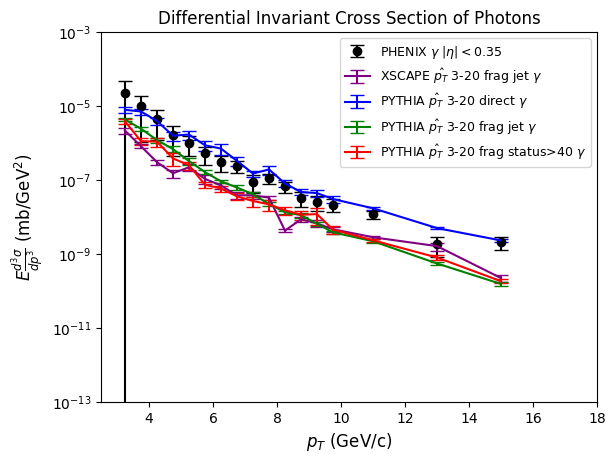

In [12]:
photon_xscape_3_20_pT, photon_xscape_3_20_cross_sec, photon_xscape_3_20_cross_sec_err = np.loadtxt('photon_pp_pTHat3_20_alldecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T
# photon_xscape_3_20_overlapped_pT, photon_xscape_3_20_overlapped_cross_sec, photon_xscape_3_20_overlapped_cross_sec_err = np.loadtxt('test_combined_4_overlappingv2.txt').T
photon_xscape_frag_3_20_pT, photon_xscape_frag_3_20_cross_sec, photon_xscape_frag_3_20_cross_sec_err = np.loadtxt('photon_pp_pTHat3_20_alldecayoff_frag_cross_sec_data_binning_1M_fixedPID.txt').T

photon_pythia_3_20_pT, photon_pythia_3_20_cross_sec, photon_pythia_3_20_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat3_20_alldecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_pythia_hadronoff_3_20_pT, photon_pythia_hadronoff_3_20_cross_sec, photon_pythia_hadronoff_3_20_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat3_20_hadrondecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_pythia_frag_jet_3_20_pT, photon_pythia_frag_jet_3_20_cross_sec, photon_pythia_frag_jet_3_20_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat3_20_frag_photon_noprompt_jet_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_pythia_frag_status40_3_20_pT, photon_pythia_frag_status40_3_20_cross_sec, photon_pythia_frag_status40_3_20_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat3_20_frag_photon_statuscode_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_pythia_frag_status50_3_20_pT, photon_pythia_frag_status50_3_20_cross_sec, photon_pythia_frag_status50_3_20_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat3_20_frag_photon_statuscode50_60_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_pythia_frag_status51_3_20_pT, photon_pythia_frag_status51_3_20_cross_sec, photon_pythia_frag_status51_3_20_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat3_20_frag_photon_statuscode51_cross_sec_v4_data_binning_1M_fixedPID.txt').T
# photon_pythia_iso_3_20_pT, photon_pythia_iso_3_20_cross_sec, photon_pythia_iso_3_20_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat3_20_iso_photon_cross_sec_v4_data_binning_1M_fixedPID.txt').T

# Plotting PHENIX Photon Cross Section Data
plt.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')
# plt.errorbar(existing_photon_pT, 2*photon_xscape_3_20_cross_sec, yerr=2*photon_xscape_3_20_cross_sec_err, fmt='-', capsize=5, color='red', label= 'XSCAPE $\hat{p_{T}}$ 3-20 $\gamma$')
plt.errorbar(existing_photon_pT, 2*photon_xscape_frag_3_20_cross_sec, yerr=photon_xscape_frag_3_20_cross_sec_err, fmt='-', capsize=5, color='purple', label= 'XSCAPE $\hat{p_{T}}$ 3-20 frag jet $\gamma$')
# plt.errorbar(existing_photon_pT, 2*photon_xscape_3_20_overlapped_cross_sec, yerr=2*photon_xscape_3_20_overlapped_cross_sec_err, fmt='-', capsize=5, color='magenta', label= 'XSCAPE $\hat{p_{T}}$ 3-20 overlap $\gamma$')
plt.errorbar(existing_photon_pT, 2*photon_pythia_3_20_cross_sec, yerr=2*photon_pythia_3_20_cross_sec_err, fmt='-', capsize=5, color='blue', label= 'PYTHIA $\hat{p_{T}}$ 3-20 direct $\gamma$')
# plt.errorbar(existing_photon_pT, 2*photon_pythia_hadronoff_3_20_cross_sec, yerr=2*photon_pythia_hadronoff_3_20_cross_sec_err, fmt='-', capsize=5, color='green', label= 'PYTHIA $\hat{p_{T}}$ 3-20 $\gamma$ HadronLevel:Decay = off')
plt.errorbar(existing_photon_pT, photon_pythia_frag_jet_3_20_cross_sec/2, yerr=photon_pythia_frag_jet_3_20_cross_sec_err/2, fmt='-', capsize=5, color='green', label= 'PYTHIA $\hat{p_{T}}$ 3-20 frag jet $\gamma$')
plt.errorbar(existing_photon_pT, photon_pythia_frag_status40_3_20_cross_sec, yerr=photon_pythia_frag_status40_3_20_cross_sec_err, fmt='-', capsize=5, color='red', label= 'PYTHIA $\hat{p_{T}}$ 3-20 frag status>40 $\gamma$')
# plt.errorbar(existing_photon_pT, photon_pythia_frag_status50_3_20_cross_sec, yerr=photon_pythia_frag_status50_3_20_cross_sec_err, fmt='-', capsize=5, color='green', label= 'PYTHIA $\hat{p_{T}}$ 3-20 frag 50<status<60 $\gamma$')
# plt.errorbar(existing_photon_pT, photon_pythia_frag_status51_3_20_cross_sec, yerr=photon_pythia_frag_status51_3_20_cross_sec_err, fmt='-', capsize=5, color='purple', label= 'PYTHIA $\hat{p_{T}}$ 3-20 frag status=51 $\gamma$')
# plt.errorbar(existing_photon_pT, photon_pythia_iso_3_20_cross_sec, yerr=2*photon_pythia_iso_3_20_cross_sec_err, fmt='-', capsize=5, color='green', label= 'PYTHIA $\hat{p_{T}}$ 3-20 iso $\gamma$')

plt.ylim(1e-13,1e-3)
plt.xlim(2.5,18)
plt.yscale('log')


plt.title('Differential Invariant Cross Section of Photons')
plt.xlabel('$p_T$ (GeV/c)',fontsize=12)
plt.ylabel(r'$E \frac{d^3\sigma}{dp^3}$ (mb/GeV$^2$)',fontsize=12)
# plt.title('Direct Photon Production at RHIC $\sqrt{s}=200GeV$ compared to data')
plt.legend(fontsize=9)
# plt.text(4.3, 0.0000003, 'pp, $\sqrt{s_{NN}} = 200$ GeV', fontsize=12)
# plt.text(4.3, 0.00000015, '$|\eta| < 0.35$, $(\pi^{+}+\pi^{-})/2$', fontsize=12)
plt.show()

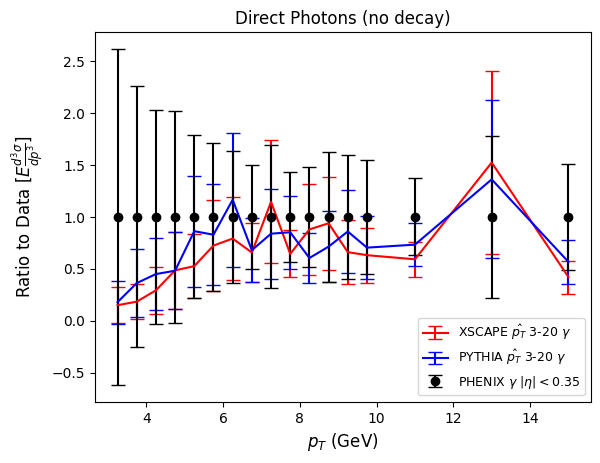

In [13]:
# Error Ratios for XSCAPE and PYTHIA
xscape_data_photon_test_ratio_err = (photon_xscape_3_20_cross_sec/existing_photon_cross_sec) * np.sqrt((photon_xscape_3_20_cross_sec_err/photon_xscape_3_20_cross_sec)**2 + (existing_photon_cross_sec_err/existing_photon_cross_sec)**2)
# xscape_data_overlap_photon_test_ratio_err = (photon_xscape_3_20_overlapped_cross_sec/existing_photon_cross_sec) * np.sqrt((photon_xscape_3_20_overlapped_cross_sec_err/photon_xscape_3_20_overlapped_cross_sec)**2 + (existing_photon_cross_sec_err/existing_photon_cross_sec)**2)
pythia_data_photon_test_ratio_err = (photon_pythia_3_20_cross_sec/existing_photon_cross_sec) * np.sqrt((photon_pythia_3_20_cross_sec_err/photon_pythia_3_20_cross_sec)**2 + (existing_photon_cross_sec_err/existing_photon_cross_sec)**2)
data_data_photon_test_ratio_err = (existing_photon_cross_sec/existing_photon_cross_sec) * np.sqrt((existing_photon_cross_sec_err/existing_photon_cross_sec)**2 + (existing_photon_cross_sec_err/existing_photon_cross_sec)**2)

# Plotting the XSCAPE / PYTHIA and PYTHIA / PYTHIA ratios
plt.errorbar(existing_photon_pT, (photon_xscape_3_20_cross_sec)/existing_photon_cross_sec, yerr=xscape_data_photon_test_ratio_err, fmt='-', color='red', capsize=5, label='XSCAPE $\hat{p_{T}}$ 3-20 $\gamma$')
# plt.errorbar(existing_photon_pT, (photon_xscape_3_20_overlapped_cross_sec)/existing_photon_cross_sec, yerr=xscape_data_overlap_photon_test_ratio_err, fmt='-', color='magenta', capsize=5, label='XSCAPE $\hat{p_{T}}$ 3-20 overlap $\gamma$')
plt.errorbar(existing_photon_pT, (photon_pythia_3_20_cross_sec)/existing_photon_cross_sec, yerr=pythia_data_photon_test_ratio_err, fmt='-', color='blue', capsize=5, label='PYTHIA $\hat{p_{T}}$ 3-20 $\gamma$')
plt.errorbar(existing_photon_pT, (existing_photon_cross_sec)/existing_photon_cross_sec, yerr=data_data_photon_test_ratio_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')

# plt.ylim(-1.5,3.5)
# plt.xlim(5,20)
plt.title('Direct Photons (no decay)')
plt.xlabel('$p_T$ (GeV)',fontsize=12)
plt.ylabel(r'Ratio to Data [$E \frac{d^{3}\sigma}{dp^{3}}$]',fontsize=12)
plt.legend(fontsize=9)
# plt.text(10.5, 1.7, 'pp, $\sqrt{s_{NN}} = 200$ GeV', fontsize=12)
# plt.text(10.5, 1.5, '$|\eta| < 0.35$, $(\pi^{+}+\pi^{-})/2$', fontsize=12)

plt.show()

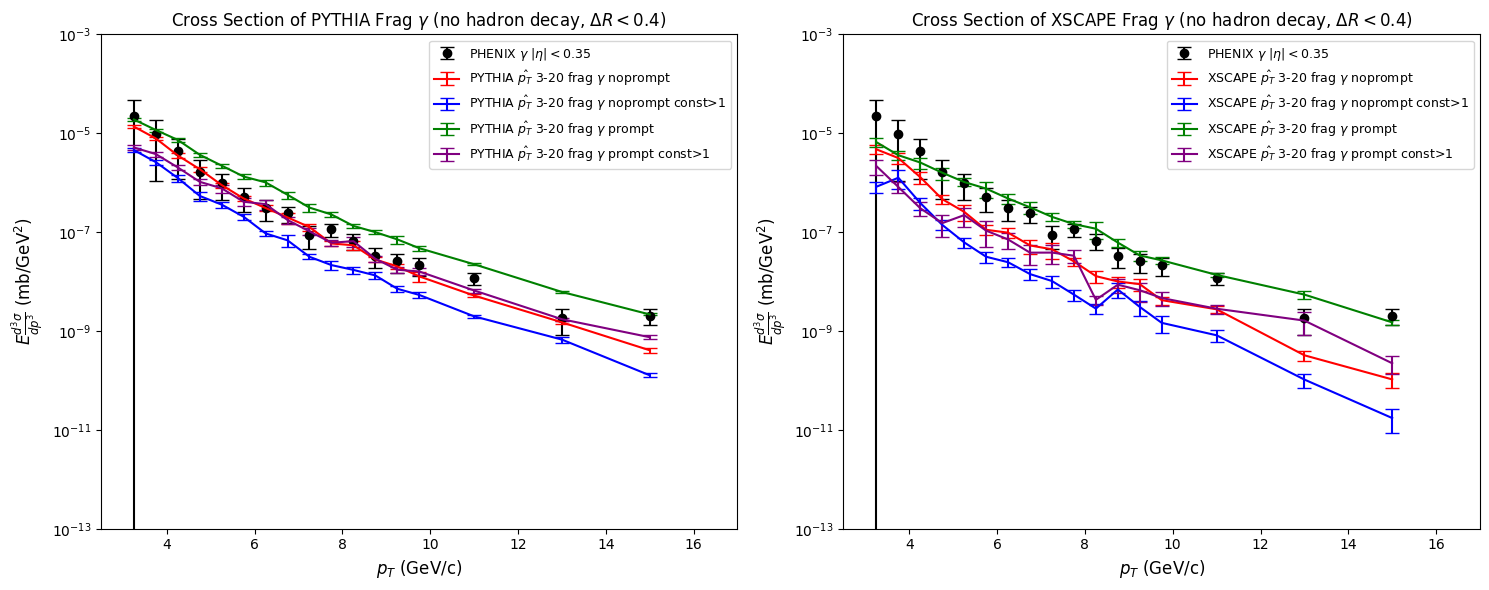

In [14]:
# PYTHIA fragmentation photons pTHat 3-20 cross sections with different selection criteria and initializations
photon_pythia_frag_jet_noprompt_deltaRcut_3_20_pT, photon_pythia_frag_jet_noprompt_deltaRcut_3_20_cross_sec, photon_pythia_frag_jet_noprompt_deltaRcut_3_20_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat3_20_frag_photon_noprompt_deltaRcut_jet_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_pythia_frag_jet_noprompt_deltaRcut_constituentcut_3_20_pT, photon_pythia_frag_jet_noprompt_deltaRcut_constituentcut_3_20_cross_sec, photon_pythia_frag_jet_noprompt_deltaRcut_constituentcut_3_20_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat3_20_frag_photon_noprompt_deltaRcut_constituentcut_jet_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_pythia_frag_jet_yesprompt_deltaRcut_3_20_pT, photon_pythia_frag_jet_yesprompt_deltaRcut_3_20_cross_sec, photon_pythia_frag_jet_yesprompt_deltaRcut_3_20_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat3_20_frag_photon_yesprompt_deltaRcut_jet_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_pythia_frag_jet_yesprompt_deltaRcut_constituentcut_3_20_pT, photon_pythia_frag_jet_yesprompt_deltaRcut_constituentcut_3_20_cross_sec, photon_pythia_frag_jet_yesprompt_deltaRcut_constituentcut_3_20_cross_sec_err = np.loadtxt('photon_Pythia_pp_pTHat3_20_frag_photon_yesprompt_deltaRcut_constituentcut_jet_cross_sec_v4_data_binning_1M_fixedPID.txt').T

# XSCAPE fragmentation photons pTHat 3-20 cross sections with different selection criteria and initializations
photon_xscape_frag_jet_noprompt_deltaRcut_3_20_pT, photon_xscape_frag_jet_noprompt_deltaRcut_3_20_cross_sec, photon_xscape_frag_jet_noprompt_deltaRcut_3_20_cross_sec_err = np.loadtxt('photon_pp_pTHat3_20_frag_photon_noprompt_deltaRcut_jet_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_xscape_frag_jet_noprompt_deltaRcut_constituentcut_3_20_pT, photon_xscape_frag_jet_noprompt_deltaRcut_constituentcut_3_20_cross_sec, photon_xscape_frag_jet_noprompt_deltaRcut_constituentcut_3_20_cross_sec_err = np.loadtxt('photon_pp_pTHat3_20_frag_photon_noprompt_deltaRcut_constituentcut_jet_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_xscape_frag_jet_yesprompt_deltaRcut_3_20_pT, photon_xscape_frag_jet_yesprompt_deltaRcut_3_20_cross_sec, photon_xscape_frag_jet_yesprompt_deltaRcut_3_20_cross_sec_err = np.loadtxt('photon_pp_pTHat3_20_frag_photon_yesprompt_deltaRcut_jet_cross_sec_v4_data_binning_1M_fixedPID.txt').T
photon_xscape_frag_jet_yesprompt_deltaRcut_constituentcut_3_20_pT, photon_xscape_frag_jet_yesprompt_deltaRcut_constituentcut_3_20_cross_sec, photon_xscape_frag_jet_yesprompt_deltaRcut_constituentcut_3_20_cross_sec_err = np.loadtxt('photon_pp_pTHat3_20_frag_photon_yesprompt_deltaRcut_constituentcut_jet_cross_sec_v4_data_binning_1M_fixedPID.txt').T


fig, (ax1, ax2) = plt.subplots(1,2,figsize=(15,6))

ax1.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')
ax1.errorbar(existing_photon_pT, photon_pythia_frag_jet_noprompt_deltaRcut_3_20_cross_sec/2, yerr=photon_pythia_frag_jet_noprompt_deltaRcut_3_20_cross_sec_err/2, fmt='-', color='red', capsize=5, label='PYTHIA $\hat{p_{T}}$ 3-20 frag $\gamma$ noprompt')
ax1.errorbar(existing_photon_pT, photon_pythia_frag_jet_noprompt_deltaRcut_constituentcut_3_20_cross_sec/2, yerr=photon_pythia_frag_jet_noprompt_deltaRcut_constituentcut_3_20_cross_sec_err/2, fmt='-', color='blue', capsize=5, label='PYTHIA $\hat{p_{T}}$ 3-20 frag $\gamma$ noprompt const>1')
ax1.errorbar(existing_photon_pT, photon_pythia_frag_jet_yesprompt_deltaRcut_3_20_cross_sec/2, yerr=photon_pythia_frag_jet_yesprompt_deltaRcut_3_20_cross_sec_err/2, fmt='-', color='green', capsize=5, label='PYTHIA $\hat{p_{T}}$ 3-20 frag $\gamma$ prompt')
ax1.errorbar(existing_photon_pT, photon_pythia_frag_jet_yesprompt_deltaRcut_constituentcut_3_20_cross_sec/2, yerr=photon_pythia_frag_jet_yesprompt_deltaRcut_constituentcut_3_20_cross_sec_err/2, fmt='-', color='purple', capsize=5, label='PYTHIA $\hat{p_{T}}$ 3-20 frag $\gamma$ prompt const>1')

ax2.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')
ax2.errorbar(existing_photon_pT, 2*photon_xscape_frag_jet_noprompt_deltaRcut_3_20_cross_sec, yerr=2*photon_xscape_frag_jet_noprompt_deltaRcut_3_20_cross_sec_err, fmt='-', color='red', capsize=5, label='XSCAPE $\hat{p_{T}}$ 3-20 frag $\gamma$ noprompt')
ax2.errorbar(existing_photon_pT, 2*photon_xscape_frag_jet_noprompt_deltaRcut_constituentcut_3_20_cross_sec, yerr=2*photon_xscape_frag_jet_noprompt_deltaRcut_constituentcut_3_20_cross_sec_err, fmt='-', color='blue', capsize=5, label='XSCAPE $\hat{p_{T}}$ 3-20 frag $\gamma$ noprompt const>1')
ax2.errorbar(existing_photon_pT, 2*photon_xscape_frag_jet_yesprompt_deltaRcut_3_20_cross_sec, yerr=2*photon_xscape_frag_jet_yesprompt_deltaRcut_3_20_cross_sec_err, fmt='-', color='green', capsize=5, label='XSCAPE $\hat{p_{T}}$ 3-20 frag $\gamma$ prompt')
ax2.errorbar(existing_photon_pT, 2*photon_xscape_frag_jet_yesprompt_deltaRcut_constituentcut_3_20_cross_sec, yerr=2*photon_xscape_frag_jet_yesprompt_deltaRcut_constituentcut_3_20_cross_sec_err, fmt='-', color='purple', capsize=5, label='XSCAPE $\hat{p_{T}}$ 3-20 frag $\gamma$ prompt const>1')


# More Plotting Parameters
# PYTHIA
ax1.set_ylim(1e-13,1e-3)
ax1.set_xlim(2.5,17)
ax1.set_yscale('log')
ax1.set_title(r'Cross Section of PYTHIA Frag $\gamma$ (no hadron decay, $\Delta R<0.4$)')
ax1.set_xlabel('$p_T$ (GeV/c)',fontsize=12)
ax1.set_ylabel(r'$E \frac{d^3\sigma}{dp^3}$ (mb/GeV$^2$)',fontsize=12)
ax1.legend(fontsize=9)

# XSCAPE
ax2.set_ylim(1e-13,1e-3)
ax2.set_xlim(2.5,17)
ax2.set_yscale('log')
ax2.set_title(r'Cross Section of XSCAPE Frag $\gamma$ (no hadron decay, $\Delta R<0.4$)')
ax2.set_xlabel('$p_T$ (GeV/c)',fontsize=12)
ax2.set_ylabel(r'$E \frac{d^3\sigma}{dp^3}$ (mb/GeV$^2$)',fontsize=12)
ax2.legend(fontsize=9)

# # 3-20 pTHat
# ax3.set_ylim(1e-13,1e-3)
# ax3.set_xlim(2.5,17)
# ax3.set_yscale('log')
# ax3.set_title(r'Differential Invariant Cross Section of XSCAPE $\gamma$ (no hadron decay)')
# ax3.set_xlabel('$p_T$ (GeV/c)',fontsize=12)
# ax3.set_ylabel(r'$E \frac{d^3\sigma}{dp^3}$ (mb/GeV$^2$)',fontsize=12)
# ax3.legend(fontsize=9)

plt.tight_layout()
# plt.title('Differential Invariant Cross Section of Direct Photons')
# plt.xlabel('$p_T$ (GeV/c)',fontsize=12)
# plt.ylabel(r'$E \frac{d^3\sigma}{dp^3}$ (mb/GeV$^2$)',fontsize=12)
# # plt.title('Direct Photon Production at RHIC $\sqrt{s}=200GeV$ compared to data')
# plt.legend(fontsize=9)
# plt.text(4.3, 0.0000003, 'pp, $\sqrt{s_{NN}} = 200$ GeV', fontsize=12)
# plt.text(4.3, 0.00000015, '$|\eta| < 0.35$, $(\pi^{+}+\pi^{-})/2$', fontsize=12)
plt.show()

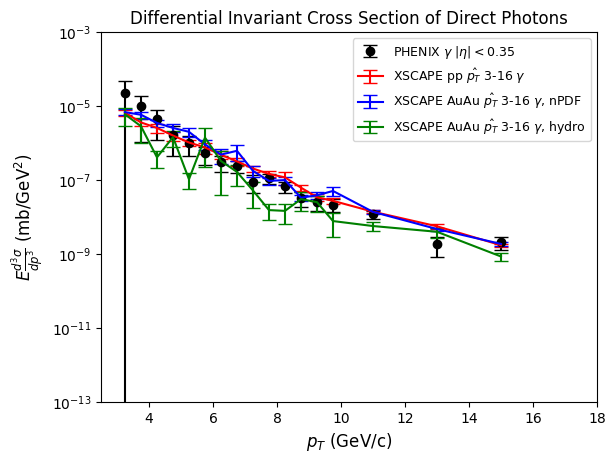

In [2]:
import numpy  as np
import matplotlib.pyplot as plt
import os
import subprocess
from IPython.display import display

existing_photon_pT, existing_photon_cross_sec, existing_photon_stat_err, existing_photon_syst_err=np.loadtxt('Existing Data for Cross Sections.txt').T
existing_photon_cross_sec_err = np.sqrt(existing_photon_stat_err**2+existing_photon_syst_err**2)

photon_xscape_pp_3_16_pT, photon_xscape_pp_3_16_cross_sec, photon_xscape_pp_3_16_cross_sec_err = np.loadtxt('photon_pp_pTHat3_20_alldecayoff_cross_sec_v4_data_binning_1M_fixedPID.txt').T
# photon_xscape_pp_3_20_pT_integral = np.trapz(photon_xscape_pp_3_20_cross_sec, photon_xscape_pp_3_20_pT)

photon_xscape_AuAu_3_16_pT, photon_xscape_AuAu_3_16_cross_sec, photon_xscape_AuAu_3_16_cross_sec_err = np.loadtxt('photon_AuAu_pTHat3_20_alldecayoff_direct_cross_sec_data_binning_1M.txt').T
photon_xscape_AuAu_hydro_3_16_pT, photon_xscape_AuAu_hydro_3_16_cross_sec, photon_xscape_AuAu_hydro_3_16_cross_sec_err = np.loadtxt('photon_AuAu_pTHat3_16_hard_sector_hydro_cross_sec_centrality0_10_10k_events.txt').T
# photon_xscape_AuAu_3_20_1M_pT, photon_xscape_AuAu_3_20_1M_cross_sec, photon_xscape_AuAu_3_20_1M_cross_sec_err = np.loadtxt('photon_AuAu_pTHat3_20_alldecayoff_prompt_nohydro_direct_cross_sec_1M.txt').T
# photon_xscape_AuAu_3_20_10M_pT, photon_xscape_AuAu_3_20_10M_cross_sec, photon_xscape_AuAu_3_20_10M_cross_sec_err = np.loadtxt('photon_AuAu_pTHat3_20_alldecayoff_prompt_nohydro_direct_cross_sec_10M.txt').T
# photon_xscape_AuAu_3_20_10M_1_pT, photon_xscape_AuAu_3_20_10M_1_cross_sec, photon_xscape_AuAu_3_20_10M_1_cross_sec_err = np.loadtxt('photon_AuAu_pTHat3_20_alldecayoff_prompt_nohydro_direct_cross_sec_10M_1_test.txt').T
# photon_xscape_AuAu_3_20_10M_2_pT, photon_xscape_AuAu_3_20_10M_2_cross_sec, photon_xscape_AuAu_3_20_10M_2_cross_sec_err = np.loadtxt('photon_AuAu_pTHat3_20_alldecayoff_prompt_nohydro_direct_cross_sec_10M_2_test.txt').T
# photon_xscape_AuAu_3_20_10M_12_pT, photon_xscape_AuAu_3_20_10M_12_cross_sec, photon_xscape_AuAu_3_20_10M_12_cross_sec_err = np.loadtxt('photon_AuAu_pTHat3_20_alldecayoff_prompt_nohydro_direct_cross_sec_10M_15_test.txt').T

# photon_xscape_AuAu_3_20_pT_integral = np.trapz(photon_xscape_AuAu_3_20_cross_sec, photon_xscape_AuAu_3_20_pT)

# Plotting PHENIX Photon Cross Section Data
plt.errorbar(existing_photon_pT, existing_photon_cross_sec, yerr=existing_photon_cross_sec_err, fmt='o', color='black', capsize=5, label='PHENIX $\gamma$ $|\eta|<0.35$')
plt.errorbar(photon_xscape_pp_3_16_pT, 2*photon_xscape_pp_3_16_cross_sec, yerr=2*photon_xscape_pp_3_16_cross_sec_err, fmt='-', capsize=5, color='red', label= 'XSCAPE pp $\hat{p_{T}}$ 3-16 $\gamma$')
# plt.errorbar(existing_photon_pT, 2*photon_xscape_AuAu_3_20_cross_sec, yerr=2*photon_xscape_AuAu_3_20_cross_sec_err, fmt='-', capsize=5, color='blue', label= 'XSCAPE AuAu $\hat{p_{T}}$ 3-20 direct $\gamma$, nPDF, 1M events')
plt.errorbar(photon_xscape_AuAu_3_16_pT, 2*photon_xscape_AuAu_3_16_cross_sec, yerr=2*photon_xscape_AuAu_3_16_cross_sec_err, fmt='-', capsize=5, color='blue', label= 'XSCAPE AuAu $\hat{p_{T}}$ 3-16 $\gamma$, nPDF')
plt.errorbar(photon_xscape_AuAu_hydro_3_16_pT, photon_xscape_AuAu_hydro_3_16_cross_sec/10, yerr=photon_xscape_AuAu_hydro_3_16_cross_sec_err/10, fmt='-', capsize=5, color='green', label= 'XSCAPE AuAu $\hat{p_{T}}$ 3-16 $\gamma$, hydro')
# plt.errorbar(existing_photon_pT, photon_xscape_AuAu_3_20_10M_1_cross_sec, yerr=photon_xscape_AuAu_3_20_10M_1_cross_sec_err, fmt='-', capsize=5, color='green', label= 'XSCAPE AuAu $\hat{p_{T}}$ 3-20 direct $\gamma$, nPDF, 10M events 1')
# plt.errorbar(existing_photon_pT, photon_xscape_AuAu_3_20_10M_2_cross_sec, yerr=photon_xscape_AuAu_3_20_10M_2_cross_sec_err, fmt='-', capsize=5, color='orange', label= 'XSCAPE AuAu $\hat{p_{T}}$ 3-20 direct $\gamma$, nPDF, 10M events 2')
# plt.errorbar(existing_photon_pT, photon_xscape_AuAu_3_20_10M_12_cross_sec, yerr=photon_xscape_AuAu_3_20_10M_12_cross_sec_err, fmt='-', capsize=5, color='magenta', label= 'XSCAPE AuAu $\hat{p_{T}}$ 3-20 direct $\gamma$, nPDF, 10M events 5 total')

plt.ylim(1e-13,1e-3)
plt.xlim(2.5,18)
plt.yscale('log')


plt.title('Differential Invariant Cross Section of Direct Photons')
plt.xlabel('$p_T$ (GeV/c)',fontsize=12)
plt.ylabel(r'$E \frac{d^3\sigma}{dp^3}$ (mb/GeV$^2$)',fontsize=12)
# plt.title('Direct Photon Production at RHIC $\sqrt{s}=200GeV$ compared to data')
plt.legend(fontsize=9)
# plt.text(4.3, 0.0000003, 'pp, $\sqrt{s_{NN}} = 200$ GeV', fontsize=12)
# plt.text(4.3, 0.00000015, '$|\eta| < 0.35$, $(\pi^{+}+\pi^{-})/2$', fontsize=12)
plt.show()

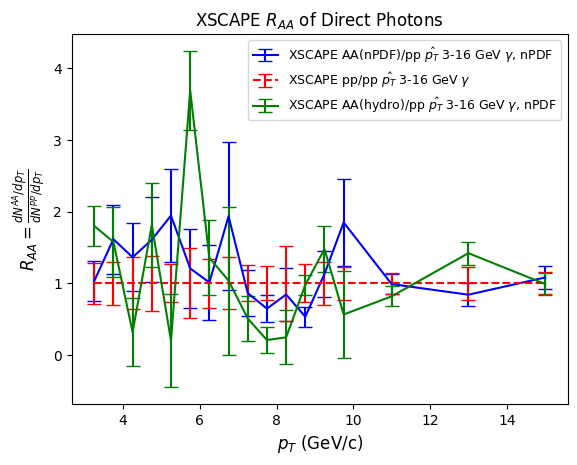

In [3]:
pp_AuAu_photon_RAA_ratio_err = ((photon_xscape_AuAu_3_16_cross_sec)/photon_xscape_pp_3_16_cross_sec) * np.sqrt(((photon_xscape_AuAu_3_16_cross_sec_err/10)/(photon_xscape_AuAu_3_16_cross_sec/10))**2 + (photon_xscape_pp_3_16_cross_sec_err/photon_xscape_pp_3_16_cross_sec)**2)
pp_pp_photon_RAA_ratio_err = (photon_xscape_pp_3_16_cross_sec/photon_xscape_pp_3_16_cross_sec) * np.sqrt((photon_xscape_pp_3_16_cross_sec_err/photon_xscape_pp_3_16_cross_sec)**2 + (photon_xscape_pp_3_16_cross_sec_err/photon_xscape_pp_3_16_cross_sec)**2)
pp_AuAu_hydro_photon_RAA_ratio_err = ((photon_xscape_AuAu_hydro_3_16_cross_sec/10)/photon_xscape_pp_3_16_cross_sec) * np.sqrt(((photon_xscape_AuAu_hydro_3_16_cross_sec_err/10)/(photon_xscape_AuAu_hydro_3_16_cross_sec/10))**2 + (photon_xscape_pp_3_16_cross_sec_err/photon_xscape_pp_3_16_cross_sec)**2)

plt.errorbar(photon_xscape_AuAu_3_16_pT, (photon_xscape_AuAu_3_16_cross_sec)/(photon_xscape_pp_3_16_cross_sec), yerr=pp_AuAu_photon_RAA_ratio_err, fmt='-', color='blue', capsize=5, label='XSCAPE AA(nPDF)/pp $\hat{p_{T}}$ 3-16 GeV $\gamma$, nPDF')
plt.errorbar(photon_xscape_pp_3_16_pT, (photon_xscape_pp_3_16_cross_sec)/(photon_xscape_pp_3_16_cross_sec), yerr=pp_pp_photon_RAA_ratio_err, fmt='--', color='red', capsize=5, label='XSCAPE pp/pp $\hat{p_{T}}$ 3-16 GeV $\gamma$')
plt.errorbar(photon_xscape_AuAu_hydro_3_16_pT, (photon_xscape_AuAu_hydro_3_16_cross_sec/10)/(photon_xscape_pp_3_16_cross_sec), yerr=pp_AuAu_photon_RAA_ratio_err, fmt='-', color='green', capsize=5, label='XSCAPE AA(hydro)/pp $\hat{p_{T}}$ 3-16 GeV $\gamma$, nPDF')

# plt.errorbar(existing_photon_pT, 2*photon_xscape_pp_3_20_cross_sec, yerr=photon_xscape_pp_3_20_cross_sec_err, fmt='-', capsize=5, color='purple', label= 'XSCAPE pp $\hat{p_{T}}$ 3-20 direct $\gamma$')
# plt.errorbar(existing_photon_pT, 2*photon_xscape_AuAu_3_20_cross_sec, yerr=2*photon_xscape_AuAu_3_20_cross_sec_err, fmt='-', capsize=5, color='blue', label= 'XSCAPE AuAu $\hat{p_{T}}$ 3-20 direct $\gamma$')

# plt.ylim(0,2)
# plt.xlim(2.5,18)
# plt.yscale('log')


plt.title('XSCAPE $R_{AA}$ of Direct Photons')
plt.xlabel('$p_T$ (GeV/c)',fontsize=12)
plt.ylabel(r'$R_{AA} = \frac{dN^{AA}/dp_{T}}{dN^{pp}/dp_{T}}$',fontsize=12)
# plt.title('Direct Photon Production at RHIC $\sqrt{s}=200GeV$ compared to data')
plt.legend(fontsize=9)
# plt.text(4.3, 0.0000003, 'pp, $\sqrt{s_{NN}} = 200$ GeV', fontsize=12)
# plt.text(4.3, 0.00000015, '$|\eta| < 0.35$, $(\pi^{+}+\pi^{-})/2$', fontsize=12)
plt.show()